# Pertemuan 7 - Regresi Linear

**Nama:** Moch Faris Oldie  
**NIM:** 250401020048  
**Kelas:** IF401

## Tujuan Praktikum

Notebook ini mempraktikkan pembuatan dataset sintetis, preprocessing, pelatihan model regresi linear, evaluasi MAE/RMSE/R2, dan visualisasi hasil prediksi.

Shape dataset: (300, 4)

Deskripsi statistik:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22

5 data pertama:
   pengalaman  edu      kota       gaji
0    7.490802    0   Jakarta  21.953247
1   19.014286    1   Jakarta  46.721665
2   14.639879    2  Surabaya  34.952649
3   11.973170    2   Bandung  32.437143
4    3.120373    2   Jakarta  17.384265

Kolom setelah encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']

Train: 240 baris
Test : 60 baris

Intercept: 27.514

Koefisien model:
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292

=== Metrik Evaluasi ===
MAE  : 1.649 juta rupiah
RMSE : 2.123 juta rupiah
R2   : 0.9740 (97.4% variasi dij

<string>:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:93: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


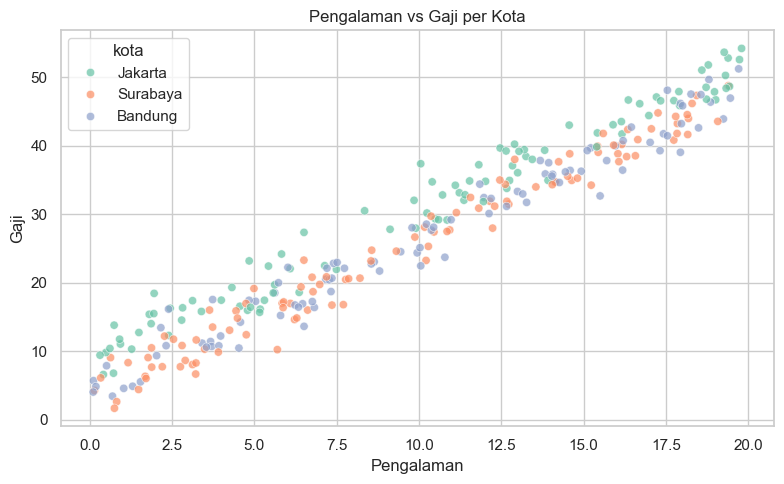

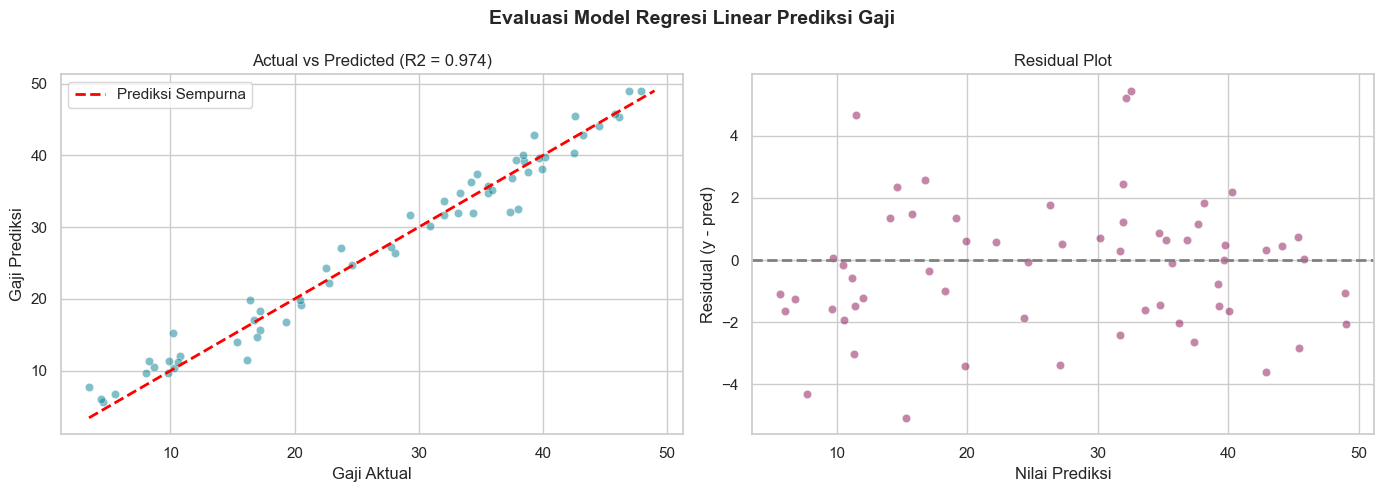

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Langkah 1: Generate dataset sintetis
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # 0=SMA, 1=D3, 2=S1
kota = np.random.choice(["Jakarta", "Surabaya", "Bandung"], n)
gaji = 3.0 + 2.2 * pengalaman + 1.5 * edu + np.where(kota == "Jakarta", 4.0, 0) + np.random.normal(0, 2, n)
df = pd.DataFrame({"pengalaman": pengalaman, "edu": edu, "kota": kota, "gaji": gaji})

print("Shape dataset:", df.shape)
print()
print("Deskripsi statistik:")
print(df.describe().round(2))
print()
print("5 data pertama:")
print(df.head())

sns.set_theme(style="whitegrid", palette="Set2")
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="pengalaman", y="gaji", hue="kota", palette="Set2", alpha=0.7)
plt.title("Pengalaman vs Gaji per Kota")
plt.xlabel("Pengalaman")
plt.ylabel("Gaji")
plt.tight_layout()
plt.show()

# Langkah 2: Preprocessing
df_encoded = pd.get_dummies(df, columns=["kota"], drop_first=True, dtype=int)
print()
print("Kolom setelah encoding:")
print(df_encoded.columns.tolist())

X = df_encoded.drop("gaji", axis=1)
y = df_encoded["gaji"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print()
print(f"Train: {X_train.shape[0]} baris")
print(f"Test : {X_test.shape[0]} baris")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Langkah 3: Latih model
model = LinearRegression()
model.fit(X_train_s, y_train)
print()
print("Intercept:", round(model.intercept_, 3))
coef_df = pd.DataFrame({"Fitur": X.columns, "Koefisien": np.round(model.coef_, 3)}).sort_values(by="Koefisien", ascending=False)
print()
print("Koefisien model:")
print(coef_df.to_string(index=False))

# Langkah 4: Evaluasi model
y_pred = model.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print()
print("=== Metrik Evaluasi ===")
print(f"MAE  : {mae:.3f} juta rupiah")
print(f"RMSE : {rmse:.3f} juta rupiah")
print(f"R2   : {r2:.4f} ({r2 * 100:.1f}% variasi dijelaskan)")
print(f"Selisih RMSE - MAE: {rmse - mae:.3f}")

# Langkah 5: Visualisasi evaluasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred, alpha=0.5, color="#028090", edgecolors="white", lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", lw=2, label="Prediksi Sempurna")
axes[0].set_xlabel("Gaji Aktual")
axes[0].set_ylabel("Gaji Prediksi")
axes[0].set_title(f"Actual vs Predicted (R2 = {r2:.3f})")
axes[0].legend()
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color="#880E4F", edgecolors="white", lw=0.5)
axes[1].axhline(0, color="gray", linestyle="--", lw=2)
axes[1].set_xlabel("Nilai Prediksi")
axes[1].set_ylabel("Residual (y - pred)")
axes[1].set_title("Residual Plot")
plt.suptitle("Evaluasi Model Regresi Linear Prediksi Gaji", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Kesimpulan

Pada pertemuan ini saya mempelajari alur dasar regresi linear, mulai dari membuat dataset, melakukan encoding dan scaling, melatih model, sampai mengevaluasi hasil dengan MAE, RMSE, dan R2. Model mampu menangkap pola hubungan pengalaman, pendidikan, dan kota terhadap gaji sintetis. Keterbatasannya adalah data masih buatan, sehingga model belum dapat langsung digunakan untuk keputusan nyata.